# 01 — Data Loading and Cabin-Class Filtering

First stage of the pipeline. This notebook establishes the analytical base used by every
notebook that follows:

1. Loads the four-route subset of `dilwong/flightprices`.
2. Characterises the cabin-class composition and removes non-coach itineraries.
3. Audits missingness overall and **per route**, to confirm the short-haul route does not
   behave differently from the long-haul one.
4. Checks temporal coverage against the documented observation window.
5. Persists a cleaned frame for downstream notebooks.

All reusable logic lives in `src/flightprice/`; this notebook imports it rather than
redefining it, so the cleaning rules cannot drift between stages.

In [26]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

from flightprice.config import (
    COACH_ONLY_CODES, PROCESSED_DIR, US_HOLIDAYS_2022,
    SEARCH_START, SEARCH_END, FLIGHT_START, FLIGHT_END,
    FULL_TRAJECTORY_END, THANKSGIVING_2022,
    SUMMER_START, SUMMER_END, set_seeds,
)
from flightprice.data.loader import load_raw, filter_coach_only, add_route
from flightprice.plotting import set_plot_style, save_fig, PALETTE

set_seeds()
set_plot_style()
pd.set_option("display.width", 120)
pd.set_option("display.max_columns", 30)

## 1. Load the subset

The full source release is 82,138,753 rows (~31 GB) and exhausts memory under a naive
`read_csv`, so all work is done on the pre-extracted four-route subset. Only the columns
needed for modelling are read — the per-segment raw timestamps and duplicated airport codes
are dropped at load time.

In [27]:
df = load_raw()

print(f"rows    : {len(df):,}")
print(f"columns : {len(df.columns)}")
print(f"memory  : {df.memory_usage(deep=True).sum() / 1e9:.2f} GB")

rows    : 2,156,316
columns : 17
memory  : 0.36 GB


In [28]:
df.dtypes.to_frame("dtype")

,dtype
legId,str
searchDate,datetime64[us]
flightDate,datetime64[us]
startingAirport,category
destinationAirport,category
travelDuration,str
elapsedDays,int64
isBasicEconomy,bool
isRefundable,bool
isNonStop,bool


In [29]:
df.head()

,legId,searchDate,flightDate,startingAirport,destinationAirport,travelDuration,elapsedDays,isBasicEconomy,isRefundable,isNonStop,baseFare,totalFare,seatsRemaining,totalTravelDistance,segmentsDepartureTimeRaw,segmentsAirlineName,segmentsCabinCode
0,f607ec920c820295169ffc85350f24d1,2022-04-16,2022-04-17,BOS,LGA,PT1H17M,0,False,False,True,110.70,133.60,7,185.0,2022-04-17T12:00:00.000-04:00,JetBlue Airways,coach
1,aeeb2de1657bf9399660830c306aeb2e,2022-04-16,2022-04-17,BOS,LGA,PT1H17M,0,False,False,True,133.95,158.60,5,185.0,2022-04-17T12:00:00.000-04:00,American Airlines,coach
2,ce8f49affa0a0c5afbe1c8f75c23e5a7,2022-04-16,2022-04-17,BOS,LGA,PT1H19M,0,False,False,True,165.66,192.69,7,185.0,2022-04-17T09:00:00.000-04:00,JetBlue Airways,coach
3,6bf7954df5dff52a357c54a1f29ce09a,2022-04-16,2022-04-17,BOS,LGA,PT1H19M,0,False,False,True,191.70,220.68,2,185.0,2022-04-17T09:00:00.000-04:00,American Airlines,coach
4,1ef7a9f4cb7aacc698085b3a7f699b6a,2022-04-16,2022-04-17,BOS,LGA,PT1H19M,0,False,False,True,228.17,259.88,7,185.0,2022-04-17T10:00:00.000-04:00,JetBlue Airways,coach


## 2. Fare distribution before filtering

`totalFare` is the modelling target. The spread here is the baseline against which the
cabin filter is judged.

In [30]:
fare_before = df["totalFare"].describe()
fare_before.round(2).to_frame("totalFare (unfiltered)")

,totalFare (unfiltered)
count,2156316.00
mean,300.08
std,242.84
min,43.60
25%,128.60
50%,261.11
75%,401.60
max,4782.60


## 3. Cabin-class composition

`segmentsCabinCode` records the cabin of *each* leg, joined by `||`. A two-leg itinerary
flown entirely in coach therefore reads `coach||coach`. An itinerary counts as coach-only
when every leg is coach.

In [31]:
cabin_counts = df["segmentsCabinCode"].value_counts()
cabin_summary = pd.DataFrame({
    "rows": cabin_counts,
    "share_%": (cabin_counts / len(df) * 100).round(3),
})
cabin_summary.head(12)

,rows,share_%
segmentsCabinCode,,
coach,1239996,57.505
coach||coach,888293,41.195
coach||coach||coach,24339,1.129
business,1572,0.073
first,762,0.035
coach||premium coach,431,0.020
premium coach||coach,367,0.017
premium coach||premium coach,253,0.012
first||first,71,0.003


In [32]:
is_coach = df["segmentsCabinCode"].astype("string").isin(COACH_ONLY_CODES)

print(f"coach-only itineraries : {is_coach.sum():>10,}  ({is_coach.mean():.2%})")
print(f"other cabins           : {(~is_coach).sum():>10,}  ({(~is_coach).mean():.2%})")
print(f"distinct cabin codes   : {df['segmentsCabinCode'].nunique():>10,}")

coach-only itineraries :  2,152,628  (99.83%)
other cabins           :      3,688  (0.17%)
distinct cabin codes   :         24


The non-coach share is small, but it is not distributed like the rest of the data — it sits
in the upper tail of the fare distribution. The figure below is the justification for
removing it: a 0.17% row share exerts leverage on the maximum far out of proportion to its
size, which would distort both the regression target and the rolling statistics used to
define a spike.

saved -> reports/figures/01_fare_by_cabin_class.png


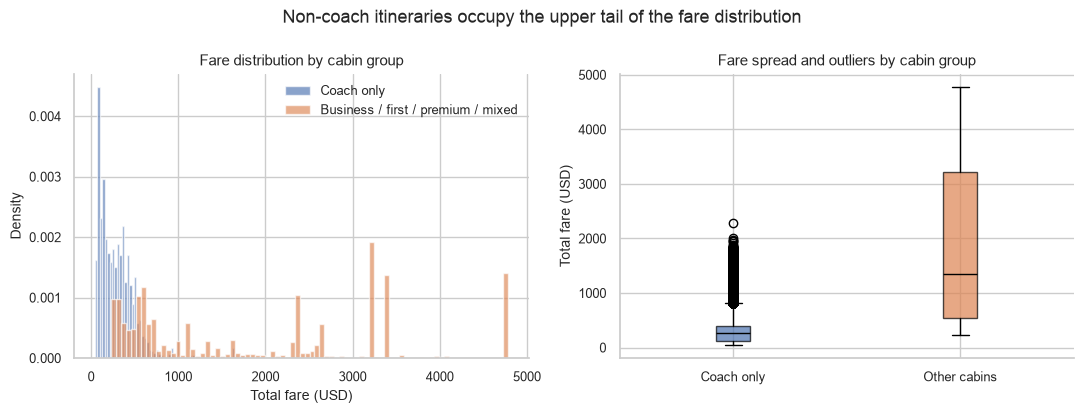

In [33]:
# The evidence for dropping business and first class.
#
# Two views of the same point. The histogram shows where each cabin group's
# fares sit; the box plot shows the tail more clearly. Non-economy tickets are
# only 0.17% of the data but sit right at the top of the price range.
#
# The number to quote: removing them drops the maximum fare from $4,782.60 to
# $2,281.61 while the MEDIAN does not change by a single cent. That is what
# tells us we cut a thin tail rather than a chunk of the real distribution.
group = np.where(is_coach, "Coach only", "Business / first / premium / mixed")

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))

# left: fare distribution by cabin group
for i, g in enumerate(["Coach only", "Business / first / premium / mixed"]):
    axes[0].hist(df.loc[group == g, "totalFare"], bins=80, alpha=0.65,
                 label=g, color=PALETTE[i], density=True)
axes[0].set_xlabel("Total fare (USD)")
axes[0].set_ylabel("Density")
axes[0].set_title("Fare distribution by cabin group")
axes[0].legend(frameon=False)

# right: where the tail actually sits
box = axes[1].boxplot(
    [df.loc[group == "Coach only", "totalFare"],
     df.loc[group != "Coach only", "totalFare"]],
    tick_labels=["Coach only", "Other cabins"], showfliers=True,
    patch_artist=True, medianprops={"color": "black"},
)
for patch, colour in zip(box["boxes"], PALETTE[:2]):
    patch.set_facecolor(colour)
    patch.set_alpha(0.7)
axes[1].set_ylabel("Total fare (USD)")
axes[1].set_title("Fare spread and outliers by cabin group")

fig.suptitle("Non-coach itineraries occupy the upper tail of the fare distribution")
fig.tight_layout()
save_fig(fig, "01_fare_by_cabin_class")
plt.show()

## 4. Apply the coach-only filter

In [34]:
clean = filter_coach_only(df)

Coach-only filter: 2,156,316 -> 2,152,628 rows (3,688 removed, 0.17%)


In [35]:
comparison = pd.DataFrame({
    "before": df["totalFare"].describe(),
    "after": clean["totalFare"].describe(),
}).round(2)
comparison["change"] = (comparison["after"] - comparison["before"]).round(2)
comparison

,before,after,change
count,2156316.00,2152628.00,-3688.00
mean,300.08,297.45,-2.63
std,242.84,227.14,-15.70
min,43.60,43.60,0.00
25%,128.60,128.60,0.00
50%,261.11,261.11,0.00
75%,401.60,401.60,0.00
max,4782.60,2281.61,-2500.99


The quartiles are unchanged and the median is identical — the filter removed tail mass, not
the body of the distribution. The maximum falls by roughly \$2,500, which is the intended
effect.

saved -> reports/figures/01_fare_distribution_before_after.png


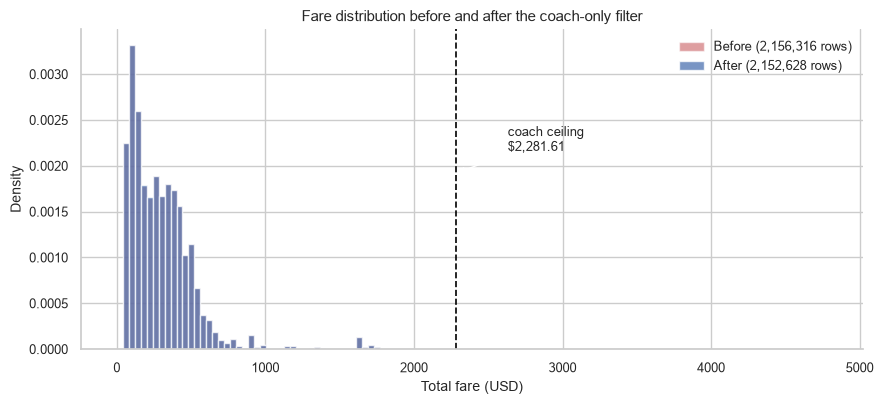

In [36]:
fig, ax = plt.subplots(figsize=(9, 4.2))

bins = np.linspace(0, df["totalFare"].max(), 120)
ax.hist(df["totalFare"], bins=bins, alpha=0.55, label=f"Before ({len(df):,} rows)",
        color=PALETTE[3], density=True)
ax.hist(clean["totalFare"], bins=bins, alpha=0.75, label=f"After ({len(clean):,} rows)",
        color=PALETTE[0], density=True)

ax.axvline(clean["totalFare"].max(), ls="--", lw=1.2, color="black")
ax.annotate(f"coach ceiling\n${clean['totalFare'].max():,.2f}",
            xy=(clean["totalFare"].max(), ax.get_ylim()[1] * 0.55),
            xytext=(clean["totalFare"].max() + 350, ax.get_ylim()[1] * 0.62),
            arrowprops={"arrowstyle": "->", "lw": 1}, fontsize=9)

ax.set_xlabel("Total fare (USD)")
ax.set_ylabel("Density")
ax.set_title("Fare distribution before and after the coach-only filter")
ax.legend(frameon=False)

fig.tight_layout()
save_fig(fig, "01_fare_distribution_before_after")
plt.show()

## 5. Route composition

Routes are treated as **directional**: JFK→LAX and LAX→JFK are separate series, since
directional demand is asymmetric and the two price differently.

In [37]:
clean = add_route(clean)

route_summary = (
    clean.groupby("route", observed=True)["totalFare"]
    .agg(rows="count", mean="mean", median="median", std="std", min="min", max="max")
    .round(2)
    .sort_values("rows", ascending=False)
)
route_summary

,rows,mean,median,std,min,max
route,,,,,,
LAX-JFK,624358,423.34,377.6,231.65,103.6,2281.61
JFK-LAX,603909,406.54,366.1,228.59,102.6,1828.59
BOS-LGA,483087,142.66,117.6,84.33,43.6,1201.60
LGA-BOS,441274,139.52,113.6,81.01,43.6,1101.60


saved -> reports/figures/01_fare_by_route.png


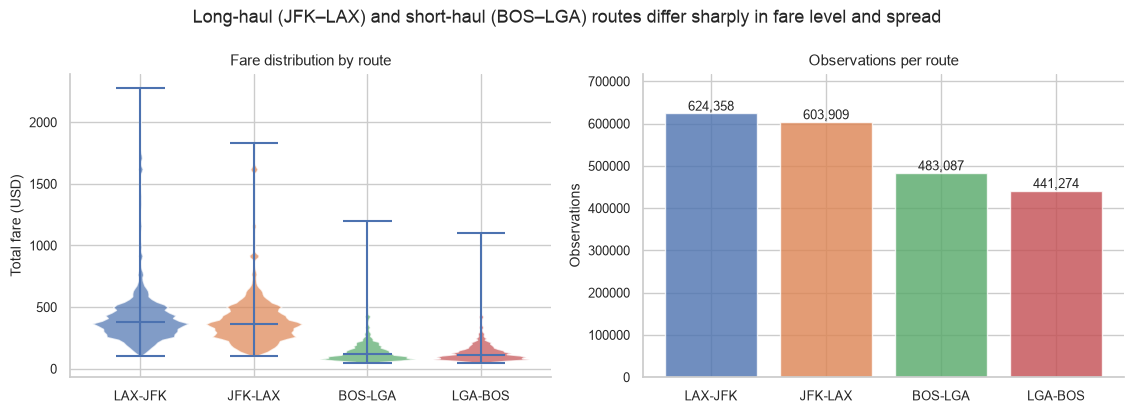

In [38]:
fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.2))

order = route_summary.index.tolist()

# left: fare distribution per route
data = [clean.loc[clean["route"] == r, "totalFare"] for r in order]
parts = axes[0].violinplot(data, showmedians=True, widths=0.85)
for i, body in enumerate(parts["bodies"]):
    body.set_facecolor(PALETTE[i % len(PALETTE)])
    body.set_alpha(0.7)
axes[0].set_xticks(range(1, len(order) + 1))
axes[0].set_xticklabels(order)
axes[0].set_ylabel("Total fare (USD)")
axes[0].set_title("Fare distribution by route")

# right: row counts
axes[1].bar(order, route_summary["rows"], color=[PALETTE[i % len(PALETTE)] for i in range(len(order))], alpha=0.8)
for i, v in enumerate(route_summary["rows"]):
    axes[1].text(i, v, f"{v:,}", ha="center", va="bottom", fontsize=9)
axes[1].set_ylabel("Observations")
axes[1].set_title("Observations per route")
axes[1].margins(y=0.15)

fig.suptitle("Long-haul (JFK–LAX) and short-haul (BOS–LGA) routes differ sharply in fare level and spread")
fig.tight_layout()
save_fig(fig, "01_fare_by_route")
plt.show()

The two route pairs separate cleanly: the transcontinental route carries both a higher
median fare and a much wider spread than the shuttle route. This is the contrast research
question 3 turns on, and it is visible before any modelling.

## 6. Missingness audit

Checked overall and **per route**. The per-route breakdown matters because the short-haul
route was never audited separately during the research phase — only the combined subset was.
If BOS–LGA were substantially more incomplete than JFK–LAX, it would need different handling.

In [39]:
nulls = clean.isna().sum()
nulls = nulls[nulls > 0]

if len(nulls):
    display(pd.DataFrame({
        "nulls": nulls,
        "share_%": (nulls / len(clean) * 100).round(3),
    }))
else:
    print("No missing values in any retained column.")

,nulls,share_%
totalTravelDistance,12857,0.597


In [40]:
null_cols = nulls.index.tolist()

per_route_nulls = (
    clean.groupby("route", observed=True)[null_cols]
    .apply(lambda g: g.isna().mean() * 100)
    .round(3)
)
per_route_nulls.columns = [f"{c} (% null)" for c in per_route_nulls.columns]
per_route_nulls

,totalTravelDistance (% null)
route,
BOS-LGA,0.485
JFK-LAX,0.580
LAX-JFK,0.636
LGA-BOS,0.688


Missingness is confined to `totalTravelDistance` and is even across all four routes. The
short-haul route is not systematically more incomplete than the long-haul route, so no
route-specific imputation strategy is required — this closes an open question carried
forward from the research phase.

## 7. Temporal coverage

The observation window bounds every seasonality claim the dissertation can make, so it is
verified against the data rather than assumed.

There are **two distinct windows** here, and conflating them is easy: the window over which
fares were *scraped* (`searchDate`), and the window of *departure* dates those searches
returned (`flightDate`). A search returns flights up to roughly two months ahead, so the
departure window extends well past the final scrape.

In [41]:
print("SEARCH window  (when fares were scraped)")
print(f"  observed : {clean['searchDate'].min().date()}  ->  {clean['searchDate'].max().date()}")
print(f"  expected : {SEARCH_START}  ->  {SEARCH_END}")
print()
print("FLIGHT window  (departure dates returned)")
print(f"  observed : {clean['flightDate'].min().date()}  ->  {clean['flightDate'].max().date()}")
print(f"  expected : {FLIGHT_START}  ->  {FLIGHT_END}")
print()
gap = (clean['flightDate'].max().date() - clean['searchDate'].max().date()).days
print(f"Departure window extends {gap} days beyond the final search date.")

SEARCH window  (when fares were scraped)
  observed : 2022-04-16  ->  2022-10-05
  expected : 2022-04-16  ->  2022-10-05

FLIGHT window  (departure dates returned)
  observed : 2022-04-17  ->  2022-11-19
  expected : 2022-04-17  ->  2022-11-19

Departure window extends 45 days beyond the final search date.


In [42]:
rows_by_month = clean.groupby(clean["flightDate"].dt.to_period("M"), observed=True).size()
pd.DataFrame({"rows": rows_by_month,
              "share_%": (rows_by_month / len(clean) * 100).round(2)})

,rows,share_%
flightDate,,
2022-04,22342,1.04
2022-05,196622,9.13
2022-06,306719,14.25
2022-07,367941,17.09
2022-08,463870,21.55
2022-09,449439,20.88
2022-10,280425,13.03
2022-11,65270,3.03


November departures **do exist** — 65,270 of them. What is absent is Thanksgiving:
24 November 2022 falls five days after the final departure date in the data. The absence of a
Thanksgiving signal is therefore a near miss of a few days, not a consequence of the data
stopping in October. Christmas is far outside the window.

In [43]:
days_ahead = (clean["flightDate"] - clean["searchDate"]).dt.days

print("Days between search and departure (all rows):")
print(days_ahead.describe().round(1).to_string())
print()
n_thanksgiving = (clean["flightDate"].dt.date == THANKSGIVING_2022).sum()
print(f"Thanksgiving 2022 ({THANKSGIVING_2022}) rows: {n_thanksgiving:,}")

Days between search and departure (all rows):
count    2152628.0
mean          27.4
std           16.2
min            1.0
25%           13.0
50%           27.0
75%           40.0
max           60.0

Thanksgiving 2022 (2022-11-24) rows: 0


### 7.1 Right-censoring of late departures

This is the constraint with the largest consequence for the spike analysis, and it is not
visible from row counts alone.

Scraping stopped on 5 October. A flight departing in mid-November was therefore only ever
observed from a long booking horizon — it was never observed close to departure, because no
search happened in that period. Since the final approach to departure is exactly where
revenue-management fare surges occur, these flights cannot exhibit an observable spike in the
sense this project defines one.

In [44]:
censoring = (
    clean.assign(dbd=days_ahead)
    .groupby(clean["flightDate"].dt.to_period("M"), observed=True)["dbd"]
    .agg(rows="count", closest_to_departure="min", furthest_from_departure="max")
)
censoring

,rows,closest_to_departure,furthest_from_departure
flightDate,,,
2022-04,22342,1,13
2022-05,196622,1,44
2022-06,306719,1,60
2022-07,367941,1,60
2022-08,463870,1,60
2022-09,449439,1,60
2022-10,280425,1,56
2022-11,65270,27,55


In [45]:
# THE CENSORING PROBLEM. This cell is the reason a whole slice of data is dropped.
#
# Price collection stopped on 5 October, but flights kept departing until
# 19 November. So a flight leaving in November was only ever priced from a
# long way out -- nobody was watching it in its final week.
#
# For each departure date we find the CLOSEST any price was recorded to it
# (.min of days-ahead). If that number is above 7, that flight was never seen
# in its final week at all.
#
# Why this matters so much: fares spike hardest in the last few days. A flight
# nobody was watching then cannot show a spike -- not because it was calm, but
# because we were not looking. Keeping those flights would drag the measured
# spike rate down and corrupt the class balance every later decision rests on.
#
# So spike analysis stops at 12 October, the last departure date we can follow
# right down to one day before it leaves. That keeps 90.3% of the rows.
min_dbd = clean.assign(dbd=days_ahead).groupby("flightDate", observed=True)["dbd"].min()
censored = min_dbd[min_dbd > 7]

print(f"Departure dates total                     : {len(min_dbd):>4}")
print(f"Never observed within 7 days of departure : {len(censored):>4}  ({len(censored)/len(min_dbd):.1%})")
print(f"First censored departure date             : {censored.index.min().date()}")
print()
print(f"Cutoff adopted for spike analysis         : {FULL_TRAJECTORY_END}")

usable = clean[clean["flightDate"].dt.date <= FULL_TRAJECTORY_END]
print(f"Rows retained under that cutoff           : {len(usable):,} ({len(usable)/len(clean):.1%})")

Departure dates total                     :  217
Never observed within 7 days of departure :   38  (17.5%)
First censored departure date             : 2022-10-13

Cutoff adopted for spike analysis         : 2022-10-12
Rows retained under that cutoff           : 1,943,082 (90.3%)


saved -> reports/figures/01_right_censoring.png


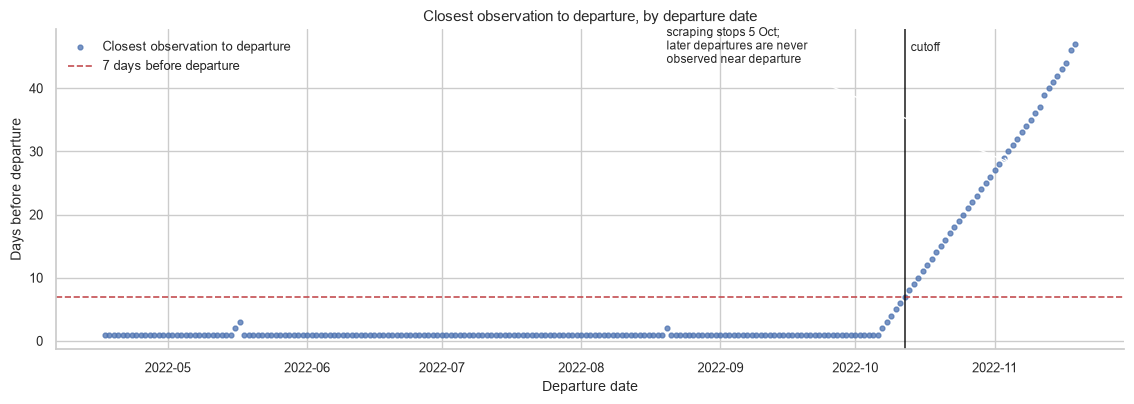

In [46]:
fig, ax = plt.subplots(figsize=(11.5, 4.2))

ax.scatter(min_dbd.index, min_dbd.values, s=12, color=PALETTE[0], alpha=0.75,
           label="Closest observation to departure")
ax.axhline(7, ls="--", lw=1.2, color=PALETTE[3], label="7 days before departure")
ax.axvline(pd.Timestamp(FULL_TRAJECTORY_END), ls="-", lw=1.4, color="black", alpha=0.7)

ax.annotate("scraping stops 5 Oct;\nlater departures are never\nobserved near departure",
            xy=(pd.Timestamp("2022-11-05"), 28), xytext=(pd.Timestamp("2022-08-20"), 44),
            arrowprops={"arrowstyle": "->", "lw": 1}, fontsize=8.5)
ax.text(pd.Timestamp(FULL_TRAJECTORY_END), ax.get_ylim()[1] * 0.96, "  cutoff",
        fontsize=8.5, va="top", ha="left")

ax.set_xlabel("Departure date")
ax.set_ylabel("Days before departure")
ax.set_title("Closest observation to departure, by departure date")
ax.legend(frameon=False, loc="upper left")

fig.tight_layout()
save_fig(fig, "01_right_censoring")
plt.show()

The pattern is unambiguous: every departure up to 12 October is observed down to one day
before departure, after which the closest available observation climbs steadily to 27 days as
the departure date moves further beyond the final scrape.

**Consequence:** the spike analysis in notebook 02 is restricted to departures on or before
12 October 2022. Retaining the censored flights would bias spike rates downward — not because
those flights lacked spikes, but because nobody was looking during the window in which spikes
occur. Days-before-departure is the primary temporal feature and is engineered properly in
notebook 03; it is previewed here to establish this constraint.

saved -> reports/figures/01_temporal_coverage.png


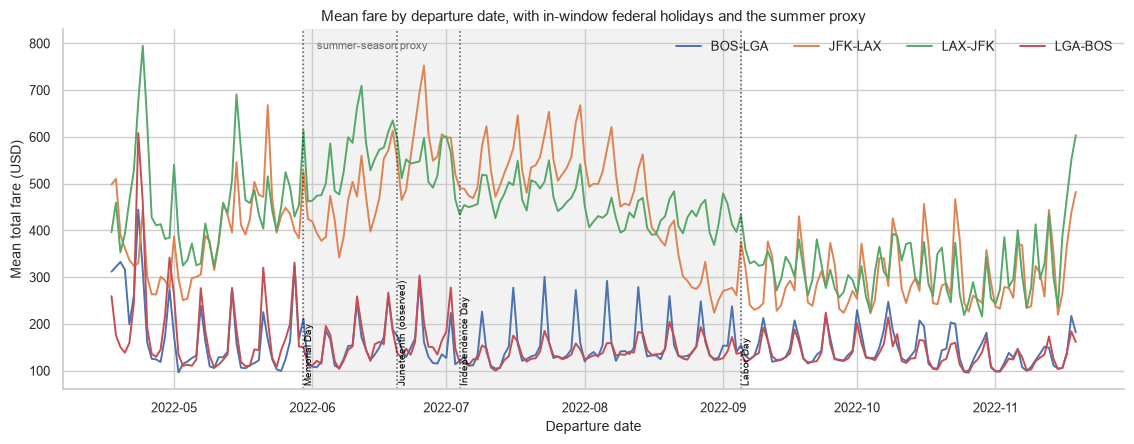

In [47]:
# The whole observation period on one chart, with the calendar marked on it.
#
# The shaded band is our stand-in for the school summer holidays, and the
# dotted lines are the four public holidays that fall inside the data.
#
# Four is the important number here. A model trying to learn a holiday effect
# gets at most three examples before it has to forecast the fourth, which is
# nowhere near enough. This chart is the visual evidence behind the
# dissertation's refusal to claim any holiday effect at all -- and it also
# shows the data ending on 19 November, five days short of Thanksgiving.
daily = (
    clean.groupby(["flightDate", "route"], observed=True)["totalFare"]
    .mean().unstack("route")
)

fig, ax = plt.subplots(figsize=(11.5, 4.6))

for i, route in enumerate(daily.columns):
    ax.plot(daily.index, daily[route], lw=1.4, label=route,
            color=PALETTE[i % len(PALETTE)])

# summer-season proxy
ax.axvspan(pd.Timestamp(SUMMER_START), pd.Timestamp(SUMMER_END),
           color="grey", alpha=0.10, zorder=0)
ax.text(pd.Timestamp(SUMMER_START) + pd.Timedelta(days=3), ax.get_ylim()[1] * 0.97,
        "summer-season proxy", fontsize=8, va="top", color="dimgrey")

# in-window federal holidays
for hol_date, label in US_HOLIDAYS_2022.items():
    ax.axvline(pd.Timestamp(hol_date), ls=":", lw=1.1, color="black", alpha=0.65)
    ax.text(pd.Timestamp(hol_date), ax.get_ylim()[0], f" {label}", rotation=90,
            fontsize=7.5, va="bottom", ha="left", color="black")

ax.set_xlabel("Departure date")
ax.set_ylabel("Mean total fare (USD)")
ax.set_title("Mean fare by departure date, with in-window federal holidays and the summer proxy")
ax.legend(frameon=False, ncol=4)

fig.tight_layout()
save_fig(fig, "01_temporal_coverage")
plt.show()

Three features of this plot constrain the rest of the project:

- **Departures run to 19 November 2022**, not to the October date on which scraping stopped.
  Thanksgiving (24 November) still falls outside by five days, so no Thanksgiving or Christmas
  signal is observable and seasonality findings remain scoped to summer travel and the four
  in-window federal holidays — but the reason is a narrow miss, not an absence of late-year
  data.
- Fare levels are visibly non-stationary across the window and the two route pairs move on
  different scales. This supports modelling the routes separately rather than pooling them.
- The short-haul routes show a strong regular oscillation that the long-haul routes lack.
  Its period is quantified below rather than asserted from the shape of the line.

### 7.2 Weekly structure

Autocorrelation of the daily mean fare distinguishes a genuinely weekly cycle from simple
day-to-day persistence: if lag-7 correlation exceeds lag-1, the series is driven by
day-of-week rather than by yesterday's level.

In [48]:
daily_mean = clean.groupby(["flightDate", "route"], observed=True)["totalFare"].mean().unstack("route")

autocorr = pd.DataFrame({
    f"lag {lag}": {r: daily_mean[r].dropna().autocorr(lag=lag) for r in daily_mean.columns}
    for lag in (1, 7, 14)
}).round(3)
autocorr["weekly-dominant"] = autocorr["lag 7"] > autocorr["lag 1"]
autocorr

,lag 1,lag 7,lag 14,weekly-dominant
BOS-LGA,0.456,0.746,0.665,True
JFK-LAX,0.845,0.842,0.696,False
LAX-JFK,0.821,0.705,0.628,False
LGA-BOS,0.515,0.766,0.676,True


In [49]:
dow = daily_mean.groupby(daily_mean.index.dayofweek).mean().round(1)
dow.index = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]

summary = dow.T
summary["peak day"] = dow.idxmax()
summary["cheapest day"] = dow.idxmin()
summary["peak / trough"] = (dow.max() / dow.min()).round(2)
summary

,Mon,Tue,Wed,Thu,Fri,Sat,Sun,peak day,cheapest day,peak / trough
route,,,,,,,,,,
BOS-LGA,134.9,125.6,126.3,134.0,154.2,243.1,174.6,Sat,Tue,1.94
JFK-LAX,420.1,345.7,353.2,385.7,397.0,402.4,487.1,Sun,Tue,1.41
LAX-JFK,418.9,367.3,398.8,439.8,419.7,429.1,482.0,Sun,Tue,1.31
LGA-BOS,134.3,118.9,121.6,133.3,148.5,224.1,182.9,Sat,Tue,1.88


The two route types behave differently, and this is the first direct evidence for research
question 3:

- **Short-haul (BOS–LGA, LGA–BOS):** lag-7 autocorrelation (≈0.75) clearly exceeds lag-1
  (≈0.46–0.52). The weekly cycle dominates. Saturday fares run roughly **1.9×** the Tuesday
  trough — a very large day-of-week effect.
- **Long-haul (JFK–LAX, LAX–JFK):** lag-1 is greater than or close to lag-7, so these series
  are driven by persistence and by the seasonal trend rather than by day of week. The
  peak-to-trough ratio is a much milder ≈1.3–1.4×, and peaks on Sunday rather than Saturday.

Day of week should therefore carry substantially more predictive weight on the short-haul
route than on the long-haul one — a hypothesis the feature-importance analysis can test
directly.

## 8. Persist the cleaned frame

Written as Parquet rather than CSV: it preserves dtypes (notably the `category` columns and
parsed dates), so downstream notebooks do not repeat the parse, and it loads an order of
magnitude faster.

In [50]:
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
out_path = PROCESSED_DIR / "coach_filtered.parquet"

clean.to_parquet(out_path, index=False)

size_mb = out_path.stat().st_size / 1e6
print(f"wrote {len(clean):,} rows -> {out_path.relative_to(PROCESSED_DIR.parents[1])} ({size_mb:.1f} MB)")

wrote 2,152,628 rows -> data/processed/coach_filtered.parquet (84.5 MB)


## Summary

| | |
|---|---|
| Rows loaded | 2,156,316 |
| Rows removed by cabin filter | 3,688 (0.17%) |
| Rows retained | 2,152,628 |
| Maximum fare before / after | \$4,782.60 → \$2,281.61 |
| Median fare before / after | \$261.11 → \$261.11 (unchanged) |
| Columns with missing values | 1 (`totalTravelDistance`, 0.6%) |
| Search window | 2022-04-16 → 2022-10-05 |
| Departure window | 2022-04-17 → 2022-11-19 |
| Departures with full trajectory | on or before 2022-10-12 (90.3% of rows) |

**Established here:**

- The cabin filter removes upper-tail leverage without shifting the body of the fare
  distribution — the median is unchanged to the cent.
- Missingness is negligible, confined to one column, and even across routes. No imputation
  strategy is needed, and the short-haul route needs no separate treatment.
- The long-haul and short-haul route pairs differ substantially in both fare level and
  spread, supporting per-route modelling and giving research question 3 a visible basis.
- The search and departure windows are **not the same**. Departures extend to 19 November,
  45 days beyond the final scrape. Thanksgiving is missed by five days, so seasonality claims
  stay scoped to summer and the four in-window federal holidays.
- **Departures after 12 October are right-censored** and are excluded from the spike analysis.
  This constraint was not identified during the research phase and materially affects how the
  spike sample is drawn.

**Next:** `02_spike_analysis.ipynb` — trace fares across successive search dates for
individual flights (restricted to departures on or before 12 October) to determine an
empirically appropriate rolling-window size, and produce the first real spike-rate estimate.
That estimate determines the class-imbalance strategy.